In [1]:
import zipfile
import osmium
import pandas as pd
from tqdm import tqdm
from shapely import Polygon
from shapely.ops import transform as shapely_transform
import matplotlib.pyplot as plt
import folium
import os
from folium.plugins import HeatMap
import geopandas as gpd


In [2]:
class PubFilter:
    pub_amen_types = ['pub', 'pub;restaurant', 'pub;bar', 'restaurant;pub;guesthouse']

    def _ispub(self, obj):
        amen = obj.tags.get('amenity')
        return amen not in self.pub_amen_types

    def node(self,n):
        return self._ispub(n)
    
    def way(self,w):
        return self._ispub(w)
    
class BarFilter:
    bar_amen_types = ['bar', 'bar;cafe', 'bar;cafe;toilets', 'bar;nightclub', 'cafe;bar', 'restaurant;bar', 'pub;bar', 'bar;arts_centre']

    def _isbar(self, obj):
        amen = obj.tags.get('amenity')
        return amen not in self.bar_amen_types

    def node(self,n):
        return self._isbar(n)
    
    def way(self,w):
        return self._isbar(w)
    
class PubBarFilter:
    pubbar_amen_types = ['bar', 'bar;cafe', 'bar;cafe;toilets', 'bar;nightclub', 'cafe;bar', 'restaurant;bar', 'pub;bar', 
                         'bar;arts_centre',
                         'pub', 'pub;restaurant', 'restaurant;pub;guesthouse']
    
    def _ispubbar(self, obj):
        amen = obj.tags.get('amenity')
        return amen not in self.pubbar_amen_types

    def node(self,n):
        return self._ispubbar(n)
    
    def way(self,w):
        return self._ispubbar(w)


fp_uk_pub = osmium.FileProcessor('data/united-kingdom-251019.osm.pbf', (osmium.osm.WAY | osmium.osm.NODE)
            ).with_filter(osmium.filter.KeyFilter('amenity')).with_filter(PubFilter()).with_locations().with_filter(osmium.filter.GeoInterfaceFilter())
fp_uk_bar = osmium.FileProcessor('data/united-kingdom-251019.osm.pbf', (osmium.osm.WAY | osmium.osm.NODE)
            ).with_filter(osmium.filter.KeyFilter('amenity')).with_filter(BarFilter()).with_locations().with_filter(osmium.filter.GeoInterfaceFilter())
fp_uk_pubbar = osmium.FileProcessor('data/united-kingdom-251019.osm.pbf', (osmium.osm.WAY | osmium.osm.NODE)
            ).with_filter(osmium.filter.KeyFilter('amenity')).with_filter(PubBarFilter()).with_locations().with_filter(osmium.filter.GeoInterfaceFilter())

fp_us_pub = osmium.FileProcessor('data/us-251019.osm.pbf', (osmium.osm.WAY | osmium.osm.NODE)
            ).with_filter(osmium.filter.KeyFilter('amenity')).with_filter(PubFilter()).with_locations().with_filter(osmium.filter.GeoInterfaceFilter())
fp_us_bar = osmium.FileProcessor('data/us-251019.osm.pbf', (osmium.osm.WAY | osmium.osm.NODE)
            ).with_filter(osmium.filter.KeyFilter('amenity')).with_filter(BarFilter()).with_locations().with_filter(osmium.filter.GeoInterfaceFilter())
fp_us_pubbar = osmium.FileProcessor('data/us-251019.osm.pbf', (osmium.osm.WAY | osmium.osm.NODE)
            ).with_filter(osmium.filter.KeyFilter('amenity')).with_filter(PubBarFilter()).with_locations().with_filter(osmium.filter.GeoInterfaceFilter())


In [ ]:
def process_with_filter(file_processor, csv_path, desc = 'getting pub/bar locs'):
    with open(csv_path, 'w') as f:
        f.write('amen,lat,lon\n')
        for o in tqdm(file_processor, desc = desc):
            if o.is_way():
                feature = o.__geo_interface__
                
                # get geometry, and process into area and centroid
                try:
                    geom = Polygon(feature["geometry"]["coordinates"])
                except ValueError:
                    # skip erroneous geometry data
                    continue

                centroid = geom.centroid  # lat long coordinates of center of building
                lat = centroid.y
                lon = centroid.x
            elif o.is_node():
                lat = o.lat
                lon = o.lon
            f.write(f'{o.tags.get("amenity").replace(",",";")},{lat},{lon}\n')

In [ ]:
for in_tuple in [(fp_uk_bar, 'data/uk-bars.csv', 'getting UK bar locs'),
              (fp_uk_pub, 'data/uk-pubs.csv', 'getting UK pub locs'),
              (fp_uk_pubbar,'data/uk-pubsbars.csv','getting UK pub/bar locs')
              ]:
    process_with_filter(*in_tuple)

In [21]:
for in_tuple in [
              (fp_us_pub, 'data/us-pubs.csv', 'getting US pub locs'),
              (fp_us_bar, 'data/us-bars.csv', 'getting US bar locs'),
              (fp_us_pubbar,'data/us-pubsbars.csv','getting US pub/bar locs')
              ]:
    process_with_filter(*in_tuple)

getting US pub locs: 5519it [00:22, 56.79it/s] 

: 

US data is possibly corrupted? Can't process the data for pubs or bars. Doesn't seem to be a memory issue.

amenity_type
pub                              38654
bar                               7125
pub / restaurant                     6
cafe / bar                           2
bar / cafe                           1
bar / cafe / toilets                 1
bar / nightclub                      1
restaurant / bar                     1
pub / bar                            1
bar / arts centre                    1
restaurant / pub / guesthouse        1
Name: count, dtype: int64

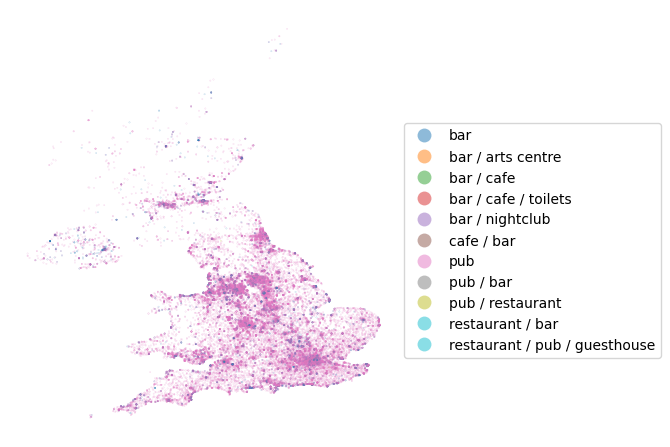

In [56]:
df = pd.read_csv('data/uk-pubsbars.csv')
df['amen'] = df['amen'].str.replace(';', ' / ').str.replace('_', ' ')
df.rename(columns = {'amen':'amenity_type'}, inplace = True)

df = gpd.GeoDataFrame(df['amenity_type'], geometry = gpd.points_from_xy(df['lon'], df['lat']))

fig, ax = plt.subplots(figsize = (5,12))
df.plot(
    column = 'amenity_type', ax = ax, autolim = False,
    marker = '.', markersize = 0.1, alpha = 0.5,
    legend=True, legend_kwds=dict(bbox_to_anchor = (1.0, 0.75))
)
ax.set_axis_off()

df['amenity_type'].value_counts()

In [51]:
pd.read_csv('data/uk-bars.csv', usecols = [1,2]).to_csv('data/uk-bars-minimal.csv',index=False)
pd.read_csv('data/uk-pubs.csv', usecols = [1,2]).to_csv('data/uk-pubs-minimal.csv',index=False)
pd.read_csv('data/uk-pubsbars.csv', usecols = [1,2]).to_csv('data/uk-pubsbars-minimal.csv',index=False)

In [53]:
print("Storage requirements for all of the UK's data:")
print("----------------------------------------------")
print("With type of institution:")
print(f"Pubs: \t\t{os.path.getsize('data/uk-pubs.csv') / 1e6} MB")
print(f"Bars: \t\t{os.path.getsize('data/uk-bars.csv') / 1e6} MB")
print(f"Pubs & bars: \t{os.path.getsize('data/uk-pubsbars.csv') / 1e6} MB")

print("\nWithout type of institution:")
print(f"Pubs: \t\t{os.path.getsize('data/uk-pubs-minimal.csv') / 1e6} MB")
print(f"Bars: \t\t{os.path.getsize('data/uk-bars-minimal.csv') / 1e6} MB")
print(f"Pubs & bars: \t{os.path.getsize('data/uk-pubsbars-minimal.csv') / 1e6} MB")

Storage requirements for all of the UK's data:
----------------------------------------------
With type of institution:
Pubs: 		1.341027 MB
Bars: 		0.218437 MB
Pubs & bars: 	1.559406 MB

Without type of institution:
Pubs: 		1.179433 MB
Bars: 		0.188983 MB
Pubs & bars: 	1.368371 MB


In [67]:
print(f"% of UK OSM data that is either a pub or bar: {os.path.getsize('data/uk-pubsbars-minimal.csv')/os.path.getsize('data/united-kingdom-251019.osm.pbf'):.2%}")

% of UK OSM data that is either a pub or bar: 0.07%
